In [1]:
import xarray as xr
import xagg
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import warnings

# Combining July 2023 2m Temperature RMSE at 24 hour lead time with Maryland Counties

## 1. Read in forecast, analysis, and climatology data for July 2023

In [2]:
fc_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/t2m/*/24/2023/07/*.nc'))
ds_fc = xr.open_mfdataset(fc_files)

In [3]:
ds_fc

<xarray.Dataset> Size: 5MB
Dimensions:    (time: 62, latitude: 81, longitude: 121)
Coordinates:
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * time       (time) datetime64[ns] 496B 2023-07-02 ... 2023-08-01T12:00:00
Data variables:
    t2m        (time, latitude, longitude) float64 5MB dask.array<chunksize=(1, 81, 121), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2024-11-24 03:29:47 GMT by grib_to_netcdf-2.25.0: grib_to_n...

In [4]:
an_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/an/0.125/t2m/2023/07/*/*.nc'))
ds_an = xr.open_mfdataset(an_files)

In [5]:
ds_an

<xarray.Dataset> Size: 10MB
Dimensions:    (time: 124, latitude: 81, longitude: 121)
Coordinates:
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * time       (time) datetime64[ns] 992B 2023-07-01 ... 2023-07-31T18:00:00
Data variables:
    t2m        (time, latitude, longitude) float64 10MB dask.array<chunksize=(4, 81, 121), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2024-11-30 22:14:05 GMT by grib_to_netcdf-2.25.0: grib_to_n...

In [6]:
clim_file = '/glade/derecho/scratch/dcalhoun/ecmwf/era5/era5_2t_climatology_1991_2020_sorted.nc'
ds_clim = xr.open_dataset(clim_file)

In [7]:
# Interpolate the climatology to the same grid as the forecast and analysis
ds_clim = ds_clim.sel(latitude=slice(ds_fc.latitude.min(), ds_fc.latitude.max()), longitude=slice(ds_fc.longitude.min(), ds_fc.longitude.max())).interp(latitude = ds_fc.latitude.values, longitude = ds_fc.longitude.values, method='nearest')

In [8]:
ds_clim

<xarray.Dataset> Size: 29MB
Dimensions:    (time: 365, latitude: 81, longitude: 121)
Coordinates:
  * time       (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
Data variables:
    2t         (time, latitude, longitude) float64 29MB 268.0 268.0 ... 289.1

## 2. Calculate RMSE

In [9]:
start = '2023-07-01'
end = '2023-07-31'
lead_time = '24'
rmse_file = '/glade/derecho/scratch/dcalhoun/ecmwf/scores/ifs/0.125/t2m/24/rmse_ifs_0.125_t2m_24_07012023_07312023.nc'
os.makedirs(os.path.dirname(rmse_file), exist_ok=True)

common_times = np.intersect1d(ds_fc['t2m'].time.values, ds_an['t2m'].time.values) # ensure all times present in both fc and an
ds_fc = ds_fc.sel(time=common_times)
t2m_fc = ds_fc['t2m'].values
t2m_an = ds_an.sel(time=common_times)['t2m'].values
ds_fc = ds_fc.assign_coords(dayofyear = pd.to_datetime(ds_fc.time.dt.strftime('2017-%m-%d')).dayofyear) # get day of year
t2m_clim = ds_clim.sel(time=ds_fc.dayofyear.values)['2t'].values # align climatology to forecast data
mse = ((t2m_fc - t2m_clim)**2).mean(axis=0) + ((t2m_an - t2m_clim)**2).mean(axis=0) - (2*(t2m_fc - t2m_clim)*(t2m_an - t2m_clim)).mean(axis=0)
rmse = np.sqrt(mse)
rmse_dataset = xr.Dataset({
                't2m_rmse': (['latitude','longitude'], rmse),
                },
                coords =
                {'latitude' : (['latitude'], ds_fc.latitude.values),
                'longitude' : (['longitude'], ds_fc.longitude.values)
                })                                           
rmse_dataset.to_netcdf(rmse_file)

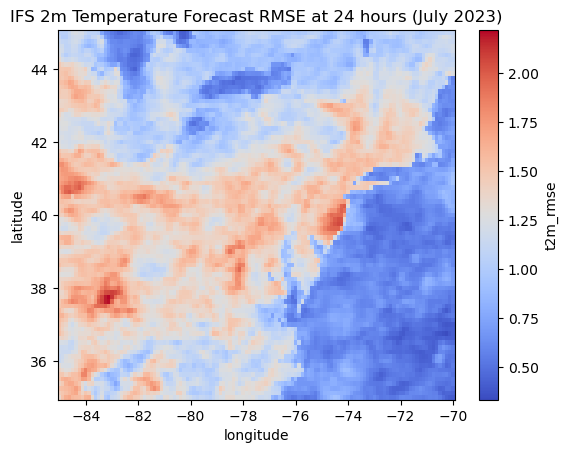

In [10]:
ds_rmse = xr.open_dataset(rmse_file)
ds_rmse['t2m_rmse'].plot(cmap='coolwarm')
plt.title('IFS 2m Temperature Forecast RMSE at 24 hours (July 2023)')
plt.show()

## 3. Aggregate RMSE

In [11]:
# Read in the shapefile
shapefile_path = '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023'
gdf = gpd.read_file(shapefile_path, columns=['GEOID', 'STATEFP', 'geometry']).to_crs('WGS84')
gdf.head()


,GEOID,STATEFP,geometry
0,01001,01,"POLYGON ((-86.41117 32.40993, -86.41615 32.407..."
1,01003,01,"MULTIPOLYGON (((-87.55444 30.27956, -87.55458 ..."
2,01005,01,"POLYGON ((-85.05603 32.06305, -85.05593 32.063..."
3,01007,01,"POLYGON ((-87.0258 33.21716, -87.02572 33.2097..."
4,01009,01,"POLYGON ((-86.44413 34.25911, -86.44433 34.256..."


In [12]:
# Maryland only
gdf_md = gdf[gdf['STATEFP'] == '24'][['GEOID', 'geometry']].reset_index(drop=True)
gdf_md

,GEOID,geometry
0,24001,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
1,24003,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3..."
2,24005,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ..."
3,24009,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3..."
4,24011,"POLYGON ((-75.72279 38.82985, -75.72236 38.824..."
5,24013,"POLYGON ((-76.88227 39.35019, -76.88225 39.350..."
6,24015,"MULTIPOLYGON (((-75.8472 39.36903, -75.84737 3..."
7,24017,"MULTIPOLYGON (((-76.85986 38.26792, -76.85976 ..."
8,24019,"MULTIPOLYGON (((-76.09107 38.1327, -76.08913 3..."
9,24021,"POLYGON ((-77.16808 39.35396, -77.16817 39.353..."


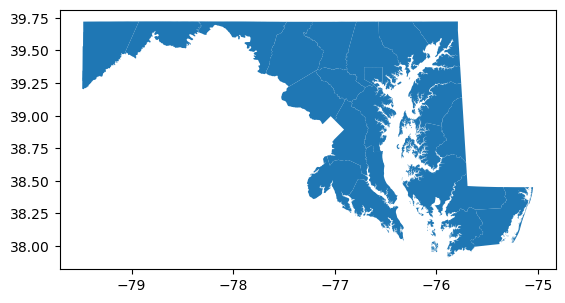

In [13]:
gdf_md.plot()
plt.show()

In [14]:
# Aggregate the RMSE data
rmse_shapefile = '/glade/derecho/scratch/dcalhoun/aggregated/county/ifs/0.125/t2m/24/rmse_ifs_0.125_t2m_24_07012023_07312023_md.shp'
os.makedirs(os.path.dirname(rmse_shapefile), exist_ok=True)
weightmap = xagg.pixel_overlaps(ds_rmse,gdf_md)
aggregated = xagg.aggregate(ds_rmse,weightmap)
with warnings.catch_warnings(action="ignore"):
    aggregated.to_shp(rmse_shapefile)

creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...


success!
adjusting grid... (this may happen because only a subset of pixels were used for aggregation for efficiency - i.e. [subset_bbox=True] in xa.pixel_overlaps())
grid adjustment successful
aggregating t2m_rmse...
all variables aggregated to polygons!
/glade/derecho/scratch/dcalhoun/aggregated/county/ifs/0.125/t2m/24/rmse_ifs_0.125_t2m_24_07012023_07312023_md.shp saved!


In [15]:
gdf_rmse = gpd.read_file(rmse_shapefile)
gdf_rmse.set_index('GEOID', inplace=True)
gdf_rmse

,t2m_rmse,geometry
GEOID,,
24001,1.410122,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
24003,1.203399,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3..."
24005,1.478603,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ..."
24009,1.257825,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3..."
24011,1.315454,"POLYGON ((-75.72279 38.82985, -75.72236 38.824..."
24013,1.609558,"POLYGON ((-76.88227 39.35019, -76.88225 39.350..."
24015,1.363546,"MULTIPOLYGON (((-75.8472 39.36903, -75.84737 3..."
24017,1.403133,"MULTIPOLYGON (((-76.85986 38.26792, -76.85976 ..."
24019,1.169683,"MULTIPOLYGON (((-76.09107 38.1327, -76.08913 3..."


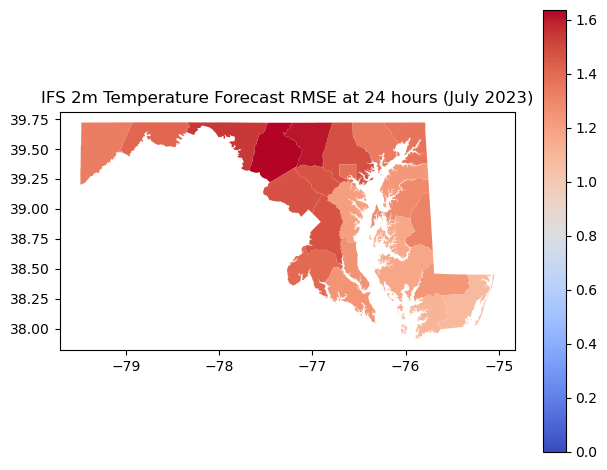

In [16]:
gdf_rmse.plot(column='t2m_rmse', legend = True, cmap='coolwarm', vmin=0, vmax=gdf_rmse['t2m_rmse'].max())
plt.title('IFS 2m Temperature Forecast RMSE at 24 hours (July 2023)')
plt.tight_layout()
plt.show()

## 4. Combine With Census Variables

In [17]:
# Read in the census data
census_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/census/data/acs_5yr_2023/county/Maryland/*.csv'))
dataframes = []
df = None
for i, census_file in enumerate(census_files):
    if i != len(census_files) - 1:
        df = pd.read_csv(census_file)
        ncols = len(df.columns)
        df = pd.read_csv(census_file, usecols=range(ncols - 4))
        dataframes.append(df)
    else:
        df = pd.read_csv(census_file)
        dataframes.append(df)
df_census = pd.concat(dataframes, axis=1)

# Clean up the census data
df_census.drop(columns=['Unnamed: 0'], inplace=True) # Drop duplicate index column
df_census['GEOID'] = df_census['GEO_ID'].str.slice(-5) # Extract the shortened GEOID from the GEO_ID column
df_census.set_index('GEOID', inplace=True) # Set GEOID as the index
df_census.drop(columns=['GEO_ID'], inplace=True) # Drop the original GEO_ID column
cols = df_census.columns.tolist()
new_order = cols[-3:] + cols[:-3]
df_census = df_census[new_order] # Reorder columns
df_census.rename(columns={'state': 'STATEFP', 'county': 'COUNTYFP'}, inplace=True) # Rename columns
df_census.head()

,NAME,STATEFP,COUNTYFP,B01001_001E,B01001_001EA,B01001_001M,B01001_001MA,B01001_002E,B01001_002EA,B01001_002M,...,B25003_003M,B25003_003MA,B25064_001E,B25064_001EA,B25064_001M,B25064_001MA,B25077_001E,B25077_001EA,B25077_001M,B25077_001MA
GEOID,,,,,,,,,,,,,,,,,,,,,
24001,"Allegany County, Maryland",24,1,67762,NaN,-555555555,*****,35357,NaN,173,...,555,NaN,786,NaN,34,NaN,149200,NaN,5832,NaN
24003,"Anne Arundel County, Maryland",24,3,590936,NaN,-555555555,*****,292506,NaN,70,...,1763,NaN,1990,NaN,33,NaN,450300,NaN,4485,NaN
24005,"Baltimore County, Maryland",24,5,849586,NaN,-555555555,*****,404133,NaN,53,...,1971,NaN,1566,NaN,20,NaN,330000,NaN,3148,NaN
24009,"Calvert County, Maryland",24,9,93791,NaN,-555555555,*****,46707,NaN,87,...,495,NaN,1701,NaN,69,NaN,440200,NaN,8554,NaN
24011,"Caroline County, Maryland",24,11,33406,NaN,-555555555,*****,16442,NaN,110,...,302,NaN,1070,NaN,59,NaN,272400,NaN,7506,NaN


In [18]:
# Merge the RMSE and census data
joined = pd.concat([gdf_rmse, df_census], axis=1)

# Remove annotation columns
columns_to_drop = joined.filter(regex='(EA|MA)$').columns
joined.drop(columns=columns_to_drop, inplace=True)

# Split estimates and margins of error into separate DataFrames
retain_columns = ['NAME', 'STATEFP', 'COUNTYFP', 'geometry', 't2m_rmse']
joined_estimates = joined[[col for col in joined.columns if col not in retain_columns and col.endswith('E')]].copy()
joined_moe = joined[[col for col in joined.columns if col not in retain_columns and col.endswith('M')]].copy()
joined_estimates.columns = joined_estimates.columns.str[:-1]
joined_moe.columns = joined_moe.columns.str[:-1]
joined_estimates = pd.concat([joined[retain_columns], joined_estimates], axis=1)
joined_moe = pd.concat([joined[retain_columns], joined_moe], axis=1)

print("Shape of joined_estimates:", joined_estimates.shape)
print("Shape of joined_moe:", joined_moe.shape)

Shape of joined_estimates: (24, 251)
Shape of joined_moe: (24, 251)


In [19]:
joined_estimates.head()

,NAME,STATEFP,COUNTYFP,geometry,t2m_rmse,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
GEOID,,,,,,,,,,,,,,,,,,,,,
24001,"Allegany County, Maryland",24,1,"POLYGON ((-78.34283 39.72226, -78.34273 39.722...",1.410122,67762,35357,1588,1900,1671,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
24003,"Anne Arundel County, Maryland",24,3,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3...",1.203399,590936,292506,18141,18728,19943,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
24005,"Baltimore County, Maryland",24,5,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ...",1.478603,849586,404133,24970,26150,27069,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
24009,"Calvert County, Maryland",24,9,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3...",1.257825,93791,46707,2543,3457,3108,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
24011,"Caroline County, Maryland",24,11,"POLYGON ((-75.72279 38.82985, -75.72236 38.824...",1.315454,33406,16442,1048,1318,939,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


In [20]:
joined_moe.head()

,NAME,STATEFP,COUNTYFP,geometry,t2m_rmse,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
GEOID,,,,,,,,,,,,,,,,,,,,,
24001,"Allegany County, Maryland",24,1,"POLYGON ((-78.34283 39.72226, -78.34273 39.722...",1.410122,-555555555,173,66,201,216,...,771,61,61,447,453,447,613,555,34,5832
24003,"Anne Arundel County, Maryland",24,3,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3...",1.203399,-555555555,70,28,844,844,...,2051,139,139,892,839,892,1778,1763,33,4485
24005,"Baltimore County, Maryland",24,5,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ...",1.478603,-555555555,53,8,1076,1075,...,2731,267,267,1404,1326,1404,2395,1971,20,3148
24009,"Calvert County, Maryland",24,9,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3...",1.257825,-555555555,87,46,321,323,...,895,69,69,409,420,409,548,495,69,8554
24011,"Caroline County, Maryland",24,11,"POLYGON ((-75.72279 38.82985, -75.72236 38.824...",1.315454,-555555555,110,93,139,142,...,445,53,53,242,245,242,345,302,59,7506


In [21]:
# Save the joined data
joined_estimates.to_file('/glade/derecho/scratch/dcalhoun/aggregated/county/ifs/0.125/t2m/24/rmse_ifs_0.125_t2m_24_07012023_07312023_md_estimates.shp')
joined_moe.to_file('/glade/derecho/scratch/dcalhoun/aggregated/county/ifs/0.125/t2m/24/rmse_ifs_0.125_t2m_24_07012023_07312023_md_moe.shp')

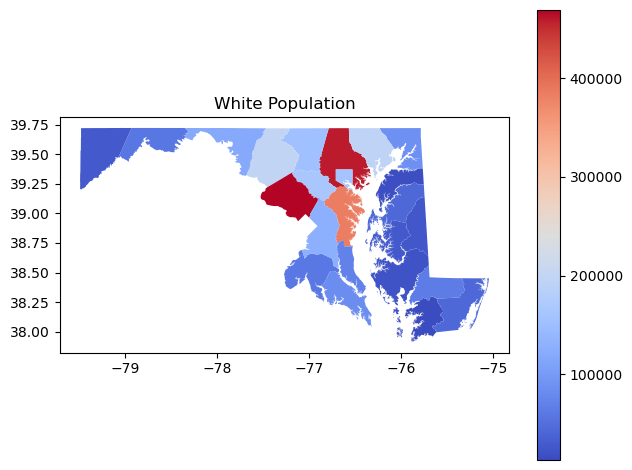

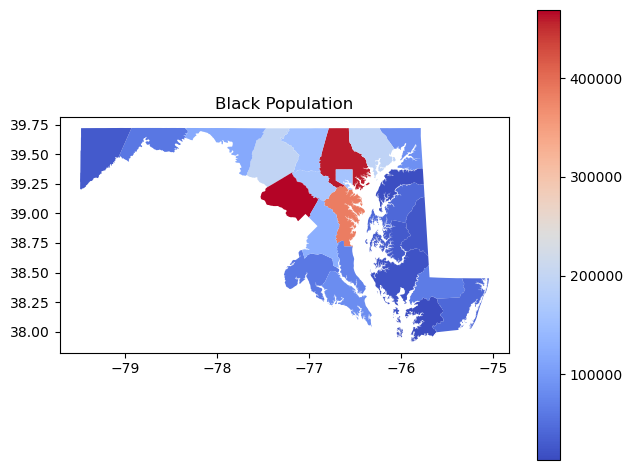

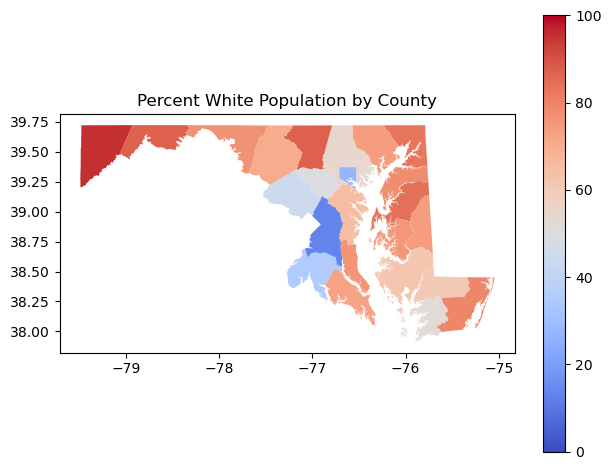

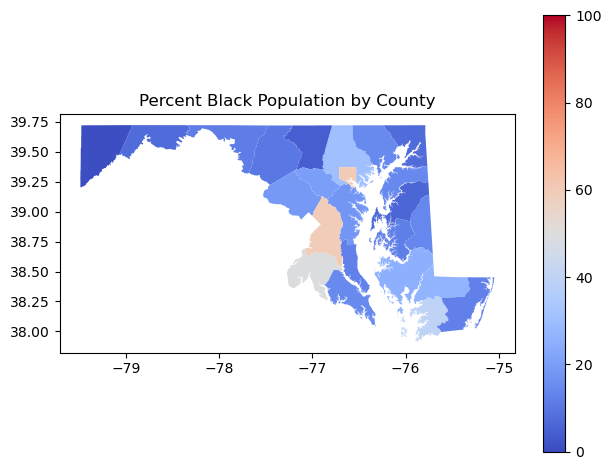

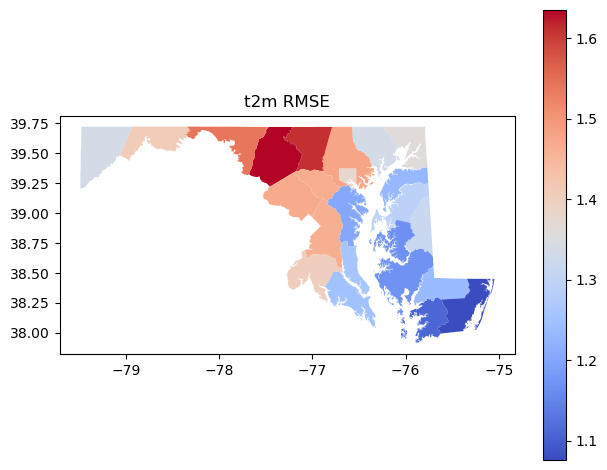

In [22]:
# Some sample plots
mydf = gpd.read_file('/glade/derecho/scratch/dcalhoun/aggregated/county/ifs/0.125/t2m/24/rmse_ifs_0.125_t2m_24_07012023_07312023_md_estimates.shp')
mydf['Percent White'] = mydf['B02001_002'] / mydf['B02001_001'] * 100
mydf['Percent Black'] = mydf['B02001_003'] / mydf['B02001_001'] * 100

mydf.plot(column='B02001_002', cmap='coolwarm', legend=True)
plt.title('White Population')
plt.tight_layout()
plt.show()

mydf.plot(column='B02001_002', cmap='coolwarm', legend=True)
plt.title('Black Population')
plt.tight_layout()
plt.show()

mydf.plot(column='Percent White', legend = True, cmap='coolwarm', vmin=0, vmax=100)
plt.title('Percent White Population by County')
plt.tight_layout()
plt.show()

mydf.plot(column='Percent Black', legend = True, cmap='coolwarm', vmin=0, vmax=100)
plt.title('Percent Black Population by County')
plt.tight_layout()
plt.show()

mydf.plot(column='t2m_rmse', cmap='coolwarm', legend=True)
plt.title('t2m RMSE')
plt.tight_layout()
plt.show()